In [2]:
from cProfile import label

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ISLP
from ISLP.models import ModelSpec as MS, summarize
import statsmodels.api as sm

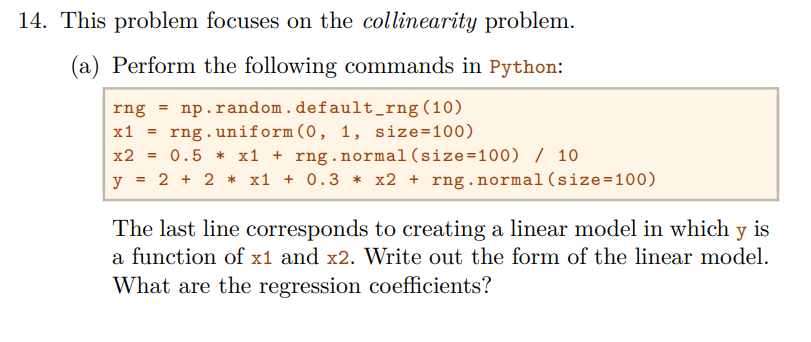
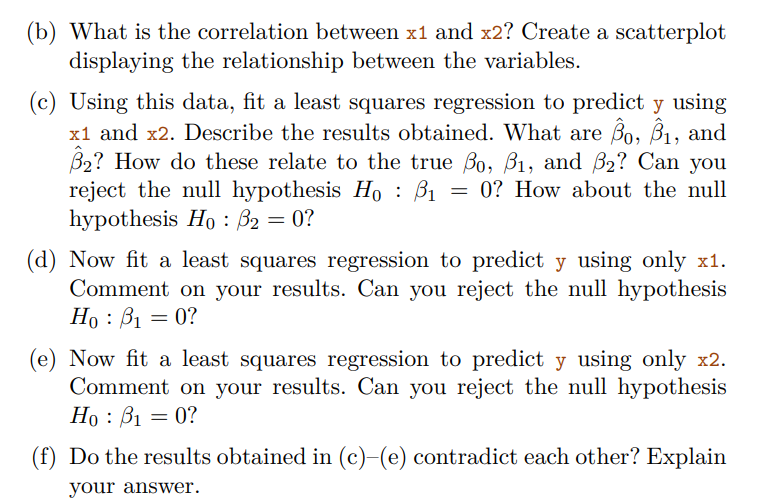
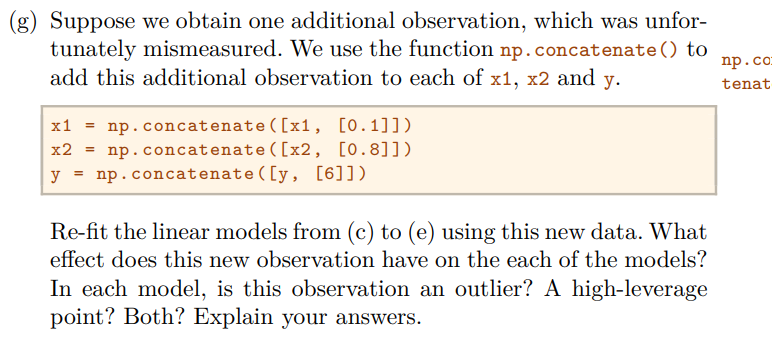

In [3]:
rng = np.random.default_rng(10)
x1 = rng.uniform(0, 1, size=100)
x2 = 0.5 * x1 + rng.normal(size=100) / 10
y = 2 + 2 * x1 + 0.3 * x2 + rng.normal(size=100)

In [4]:
df = pd.DataFrame({'X1':x1,
                   'X2':x2})
df.insert(0,'constant',1)

In [5]:
model= sm.OLS(y,df).fit()
summarize(model)

,coef,std err,t,P>|t|
constant,1.9579,0.190,10.319,0.000
X1,1.6154,0.527,3.065,0.003
X2,0.9428,0.831,1.134,0.259


In [6]:
np.corrcoef(df['X1'],df['X2'])

array([[1.       , 0.7723245],
       [0.7723245, 1.       ]])

<Axes: >

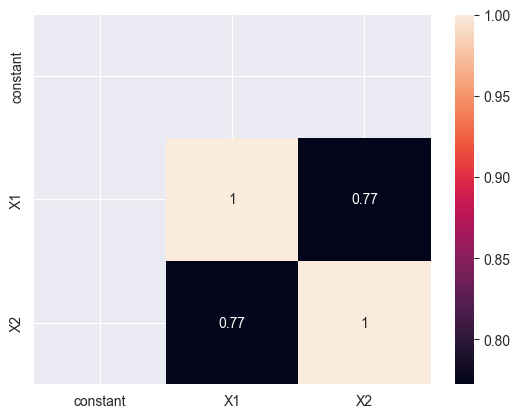

In [7]:
import seaborn as sns
corr= df.corr(method='pearson')
sns.heatmap(corr, annot=True)

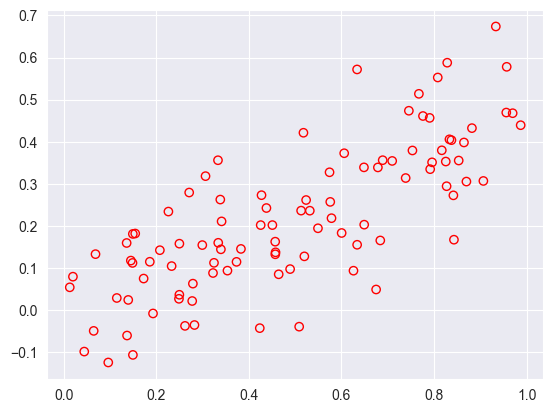

In [20]:
plt.scatter(y=df['X2'],x=df['X1'],marker= "o", facecolors='none', edgecolors='red',label='X1')

In [9]:
model1= sm.OLS(y,df[["constant","X1"]]).fit()
summarize(model1)

,coef,std err,t,P>|t|
constant,1.9371,0.189,10.242,0.0
X1,2.0771,0.335,6.196,0.0


In [10]:
model2= sm.OLS(y,df[["constant","X2"]]).fit()
summarize(model2)

,coef,std err,t,P>|t|
constant,2.3239,0.154,15.124,0.0
X2,2.9103,0.550,5.291,0.0


In [11]:
summarize(model)

,coef,std err,t,P>|t|
constant,1.9579,0.190,10.319,0.000
X1,1.6154,0.527,3.065,0.003
X2,0.9428,0.831,1.134,0.259


## Addition of the mismeasured values

In [12]:
x1 = np.concatenate([x1, [0.1]])
x2 = np.concatenate([x2, [0.8]])
y = np.concatenate([y, [6]])

In [13]:
df_mismeasured = pd.DataFrame({'X1':x1,
                   'X2':x2})
df_mismeasured.insert(0,'constant',1)

In [14]:
model_mismeasured_1= sm.OLS(y,df_mismeasured[["constant","X1"]]).fit()
summarize(model_mismeasured_1)

,coef,std err,t,P>|t|
constant,2.0739,0.201,10.310,0.0
X1,1.8760,0.358,5.236,0.0


In [15]:
model_mismeasured_2= sm.OLS(y,df_mismeasured[["constant","X2"]]).fit()
summarize(model_mismeasured_2)

,coef,std err,t,P>|t|
constant,2.2840,0.151,15.088,0.0
X2,3.1458,0.524,6.008,0.0


In [16]:
model_mismeasured= sm.OLS(y,df_mismeasured).fit()
summarize(model_mismeasured)

,coef,std err,t,P>|t|
constant,2.0618,0.192,10.720,0.000
X1,0.8575,0.466,1.838,0.069
X2,2.2663,0.705,3.216,0.002


np.int64(100)

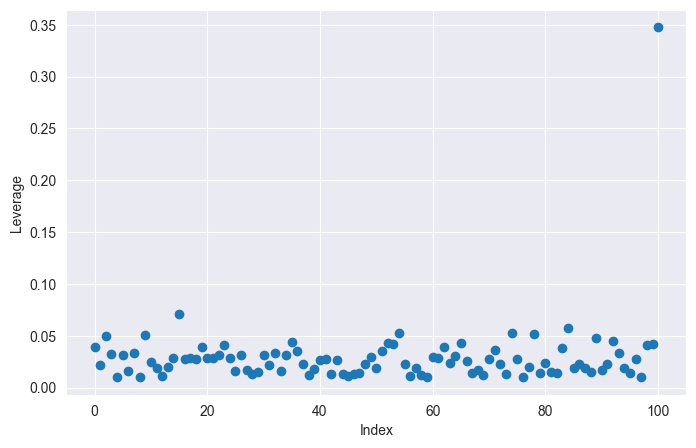

In [17]:
inf = model_mismeasured.get_influence()
ax2 = plt.subplots(figsize=(8,5))[1]
ax2.scatter(x=np.arange(df_mismeasured.shape[0]), y=inf.hat_matrix_diag)
ax2.set_xlabel("Index")
ax2.set_ylabel("Leverage")
np.argmax(inf.hat_matrix_diag)

np.int64(52)

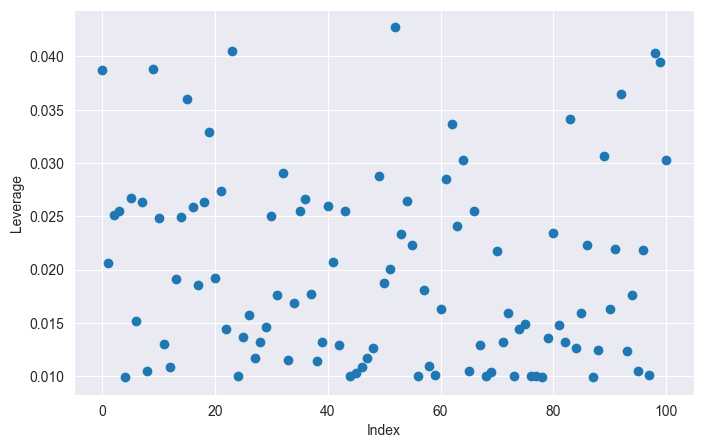

In [18]:
inf1 = model_mismeasured_1.get_influence()
ax2 = plt.subplots(figsize=(8,5))[1]
ax2.scatter(x=np.arange(df_mismeasured.shape[0]), y=inf1.hat_matrix_diag)
ax2.set_xlabel("Index")
ax2.set_ylabel("Leverage")
np.argmax(inf1.hat_matrix_diag)

np.int64(100)

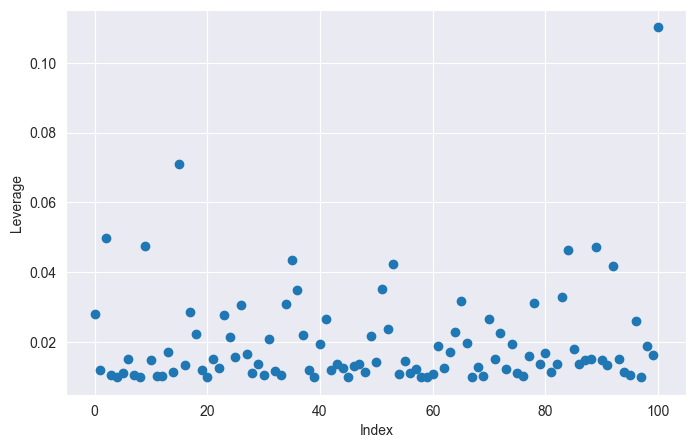

In [19]:
inf2 = model_mismeasured_2.get_influence()
ax2 = plt.subplots(figsize=(8,5))[1]
ax2.scatter(x=np.arange(df_mismeasured.shape[0]), y=inf2.hat_matrix_diag)
ax2.set_xlabel("Index")
ax2.set_ylabel("Leverage")
np.argmax(inf2.hat_matrix_diag)

In [30]:
df_mismeasured.iloc[100,2]

np.float64(0.8)

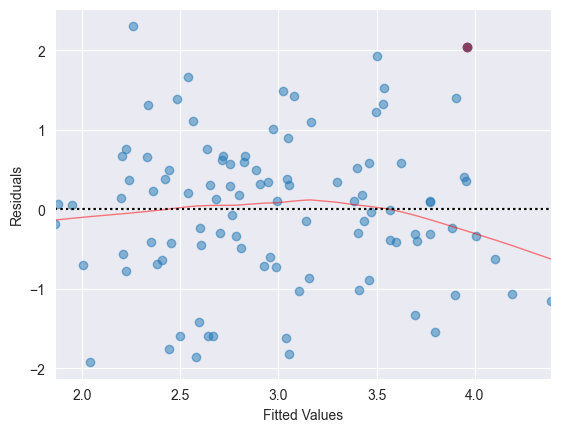

In [36]:
plt.scatter(model_mismeasured.fittedvalues[100], model_mismeasured.resid[100], marker="o", facecolor="Red", edgecolors="red")
sns.residplot(x=model_mismeasured.fittedvalues, y=y, lowess=True,scatter_kws={'alpha': 0.5}, line_kws={'color': 'red', 'lw': 1, 'alpha': 0.5})
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.axhline(0, ls=':', color='k');